In [2]:
import pandas as pd

df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (4340, 8)

Data Types:
name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object

Missing Values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate Rows: 763


In [5]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Clean column names
df.columns = df.columns.str.strip()

# Remove rows with missing values
df = df.dropna()

# Clean text columns
text_columns = ["name", "fuel", "seller_type", "transmission", "owner"]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

print("Shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Shape after cleaning: (3577, 8)

Missing values after cleaning:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [6]:
# Feature Engineering

# Use the latest year available in the dataset as the reference year
reference_year = df["year"].max()

# Calculate car age
df["car_age"] = reference_year - df["year"]

# Extract the car brand from the name
df["brand"] = df["name"].str.split().str[0]

# Display the new features
df[["name", "year", "car_age", "brand", "selling_price"]].head()

,name,year,car_age,brand,selling_price
0,Maruti 800 AC,2007,13,Maruti,60000
1,Maruti Wagon R LXI Minor,2007,13,Maruti,135000
2,Hyundai Verna 1.6 SX,2012,8,Hyundai,600000
3,Datsun RediGO T Option,2017,3,Datsun,250000
4,Honda Amaze VX i-DTEC,2014,6,Honda,450000


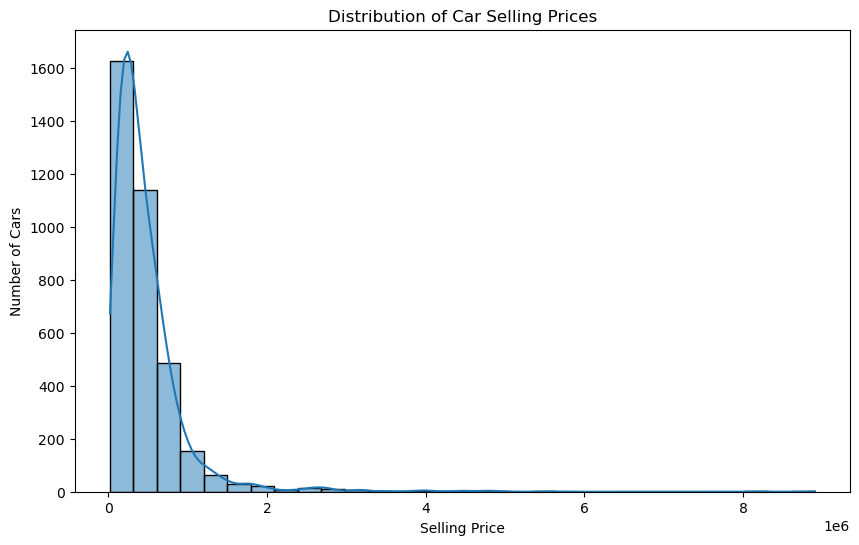

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of selling prices
plt.figure(figsize=(10, 6))
sns.histplot(df["selling_price"], bins=30, kde=True)
plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()

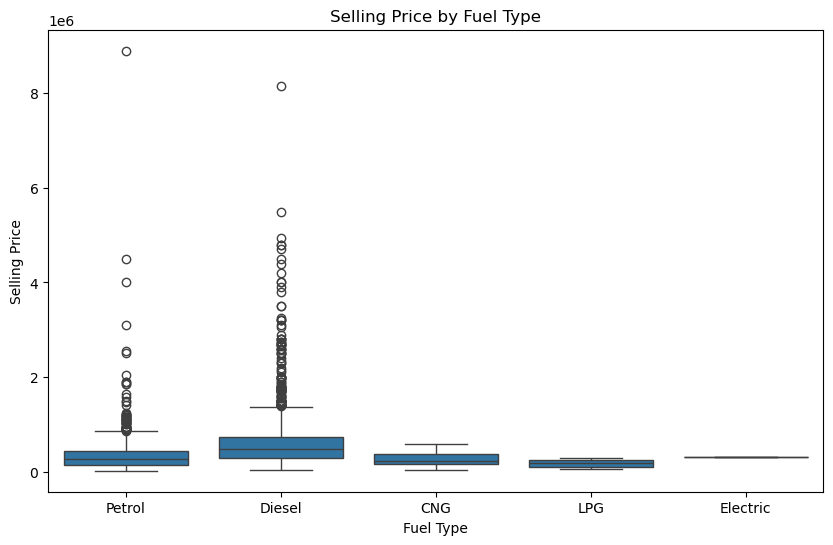

In [8]:
# Selling price by fuel type
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="fuel",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

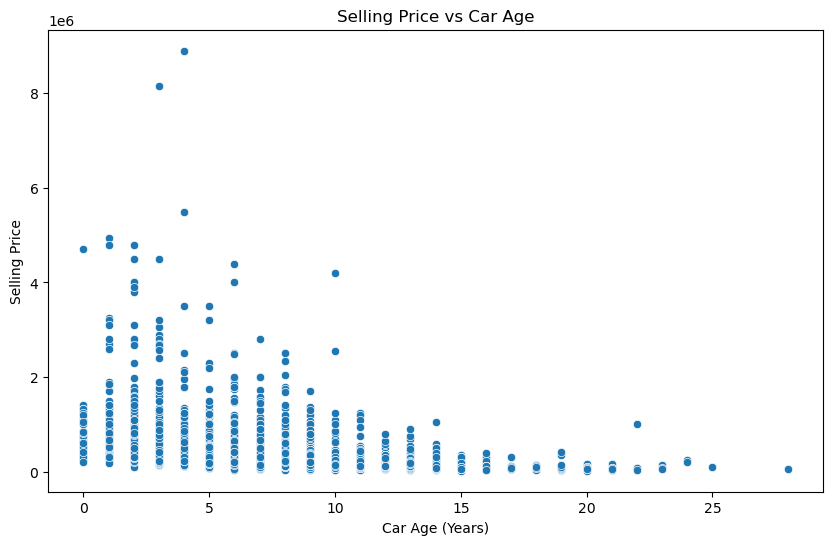

In [10]:
# Selling price vs car age
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="car_age",
    y="selling_price"
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")
plt.show()

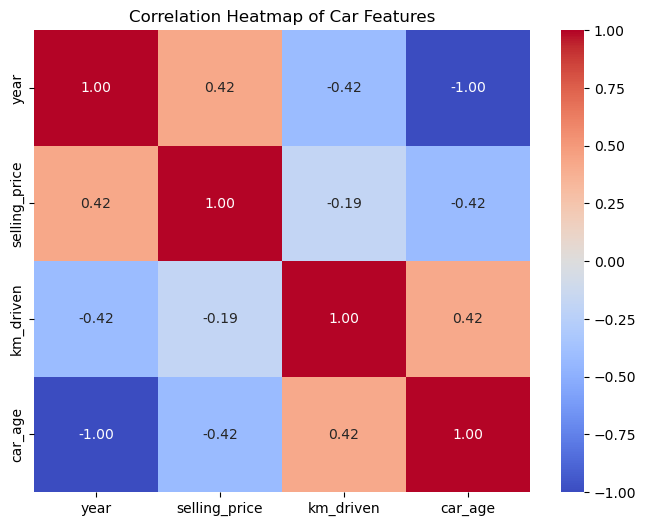

In [11]:
# Correlation heatmap for numerical features

numeric_features = [
    "year",
    "selling_price",
    "km_driven",
    "car_age"
]

correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Car Features")
plt.show()

In [14]:
X = df[
    [
        "car_age",
        "km_driven",
        "fuel",
        "seller_type",
        "transmission",
        "owner",
        "brand"
    ]
]

y = df["selling_price"]

X = pd.get_dummies(
    X,
    columns=["fuel", "seller_type", "transmission", "owner", "brand"],
    drop_first=True
)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (3577, 41)
Target shape: (3577,)


In [15]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2861, 41)
Testing data: (716, 41)


In [20]:
from sklearn.linear_model import LinearRegression

# Create and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [22]:
from sklearn.ensemble import RandomForestRegressor

# Create and train the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate Linear Regression
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

# Evaluate Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Linear Regression")
print("-----------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

print("\nRandom Forest Regressor")
print("-----------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Linear Regression
-----------------
MAE : 180194.98702152143
RMSE: 385606.0860979548
R²  : 0.538414598924799

Random Forest Regressor
-----------------------
MAE : 158587.06767489918
RMSE: 365133.52904739865
R²  : 0.5861263909095635


In [24]:
# Compare model performance

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R2 Score": [
        r2_linear,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,180194.987022,385606.086098,0.538415
1,Random Forest Regressor,158587.067675,365133.529047,0.586126


In [25]:
# Identify the best-performing model based on R² score

if r2_rf > r2_linear:
    best_model = "Random Forest Regressor"
    best_r2 = r2_rf
else:
    best_model = "Linear Regression"
    best_r2 = r2_linear

print("Best Model:", best_model)
print("Best R² Score:", best_r2)

Best Model: Random Forest Regressor
Best R² Score: 0.5861263909095635


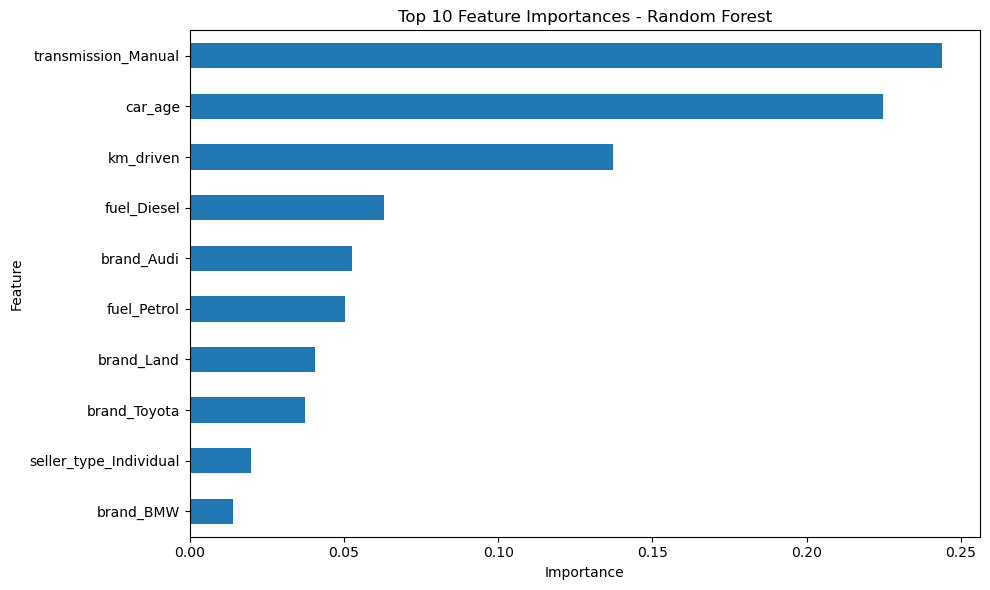

In [26]:
# Feature importance / coefficient analysis for the best model

if best_model == "Random Forest Regressor":
    importance = pd.Series(
        rf_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    importance.sort_values().plot(kind="barh")
    plt.title("Top 10 Feature Importances - Random Forest")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

else:
    importance = pd.Series(
        abs(linear_model.coef_),
        index=X.columns
    ).sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    importance.sort_values().plot(kind="barh")
    plt.title("Top 10 Feature Importance - Linear Regression")
    plt.xlabel("Absolute Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

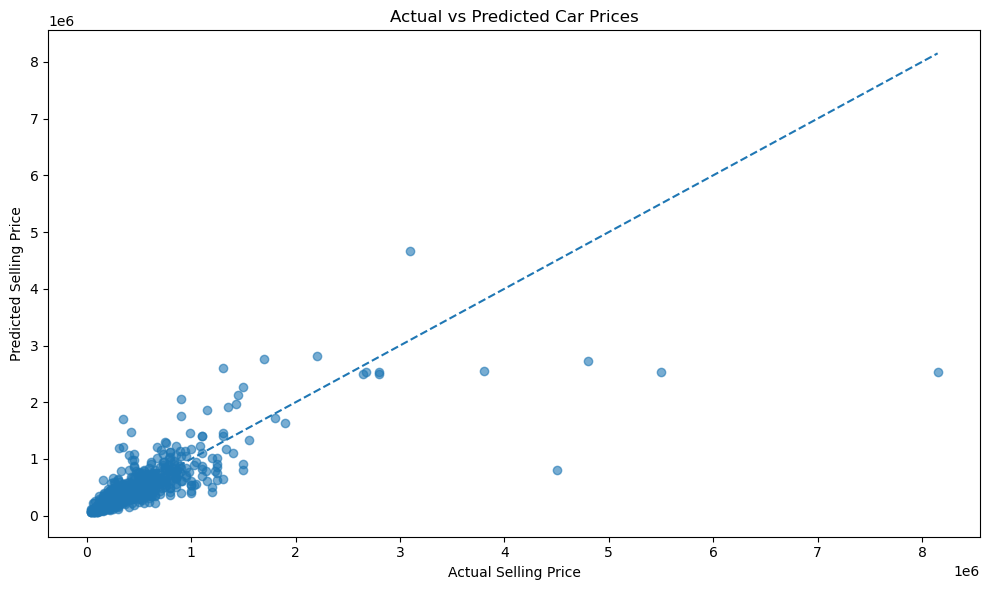

In [28]:
# Actual vs Predicted Selling Prices

if best_model == "Random Forest Regressor":
    predictions = y_pred_rf
else:
    predictions = y_pred_linear

plt.figure(figsize=(10, 6))

plt.scatter(y_test, predictions, alpha=0.6)

# Perfect prediction reference line
min_price = min(y_test.min(), predictions.min())
max_price = max(y_test.max(), predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.tight_layout()
plt.show()

## Conclusion

This project developed machine learning models to predict used car selling prices.

The dataset was cleaned and prepared by removing duplicates and missing values. Feature engineering was performed by calculating car age and extracting the car brand from the car name.

Exploratory data analysis was used to understand selling-price distributions, fuel-type differences, car-age relationships, and correlations between numerical features.

Two regression models were trained and evaluated:
- Linear Regression
- Random Forest Regressor

The models were evaluated using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Based on the R² score, the better-performing model was selected.

Feature importance analysis was also performed to identify the features that contribute most to predicting car selling prices.

Overall, this project demonstrates how machine learning and exploratory data analysis can be used to build a car price prediction system.